In [3]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import xarray as xr
import numpy as np
import os
from glob import glob
from mpl_toolkits.basemap import Basemap
from numpy import meshgrid
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter, LatitudeLocator
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, TwoSlopeNorm
import matplotlib.ticker as ticker
from matplotlib.cm import ScalarMappable
from matplotlib import colormaps
import pandas as pd
import math
from datetime import datetime
import datetime as dt
from ridgeplot import ridgeplot
import joypy
import seaborn as sns
from matplotlib import cm
import climpred
from xclim import sdba
from climpred.options import OPTIONS
import json
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from matplotlib.lines import Line2D  # For custom legend entries
import warnings
from sklearn.exceptions import UndefinedMetricWarning
import matplotlib.gridspec as gridspec
import hydroeval as he
import re
from matplotlib.colors import Normalize
import matplotlib.colors as mcolors
from matplotlib import cm, colors

from function import preprocessUtils as putils
from function import masks
from function import verifications
from function import funs as f
from function import conf
from function import loadbias
from function import quikplot as qp
from function import dataLoad
from function import conf
from function import plotCRPSS


warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

global dim_order, region_name, test_year, leads_
dim_order = conf.dim_order

test_year = 2019
leads_ = [6,13,20,27]

dir = '/glade/work/klesinger/FD_RZSM_deep_learning'
assert test_year == 2019, 'This is only the script for when the testing years are 2018-2019. Test year must = 2019.'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Create plots

In [ ]:
for region_name in ['CONUS','china','australia']:
    for obs_source in ['ERA5','GLEAM']:
        for forecast_name in ['ECMWF', 'GEFSv12']:
            plotCRPSS.plot_CRPSS_components(region_name, obs_source, forecast_name)

for region_name in ['CONUS','china','australia']:
    for obs_source in ['ERA5','GLEAM']:
        plotCRPSS.plot_CRPSS_components_combined(region_name, obs_source)

for region_name in ['CONUS','china','australia']:
    for obs_source in ['ERA5','GLEAM']:
        for week_lead in [1,2,3,4]:
            plotCRPSS.plot_CRPSS_components_seasons_by_week(region_name, obs_source,week_lead)

# Plot all of models in a single figure

/glade/derecho/scratch/klesinger/tmp/ipykernel_84343/2083783228.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.93])


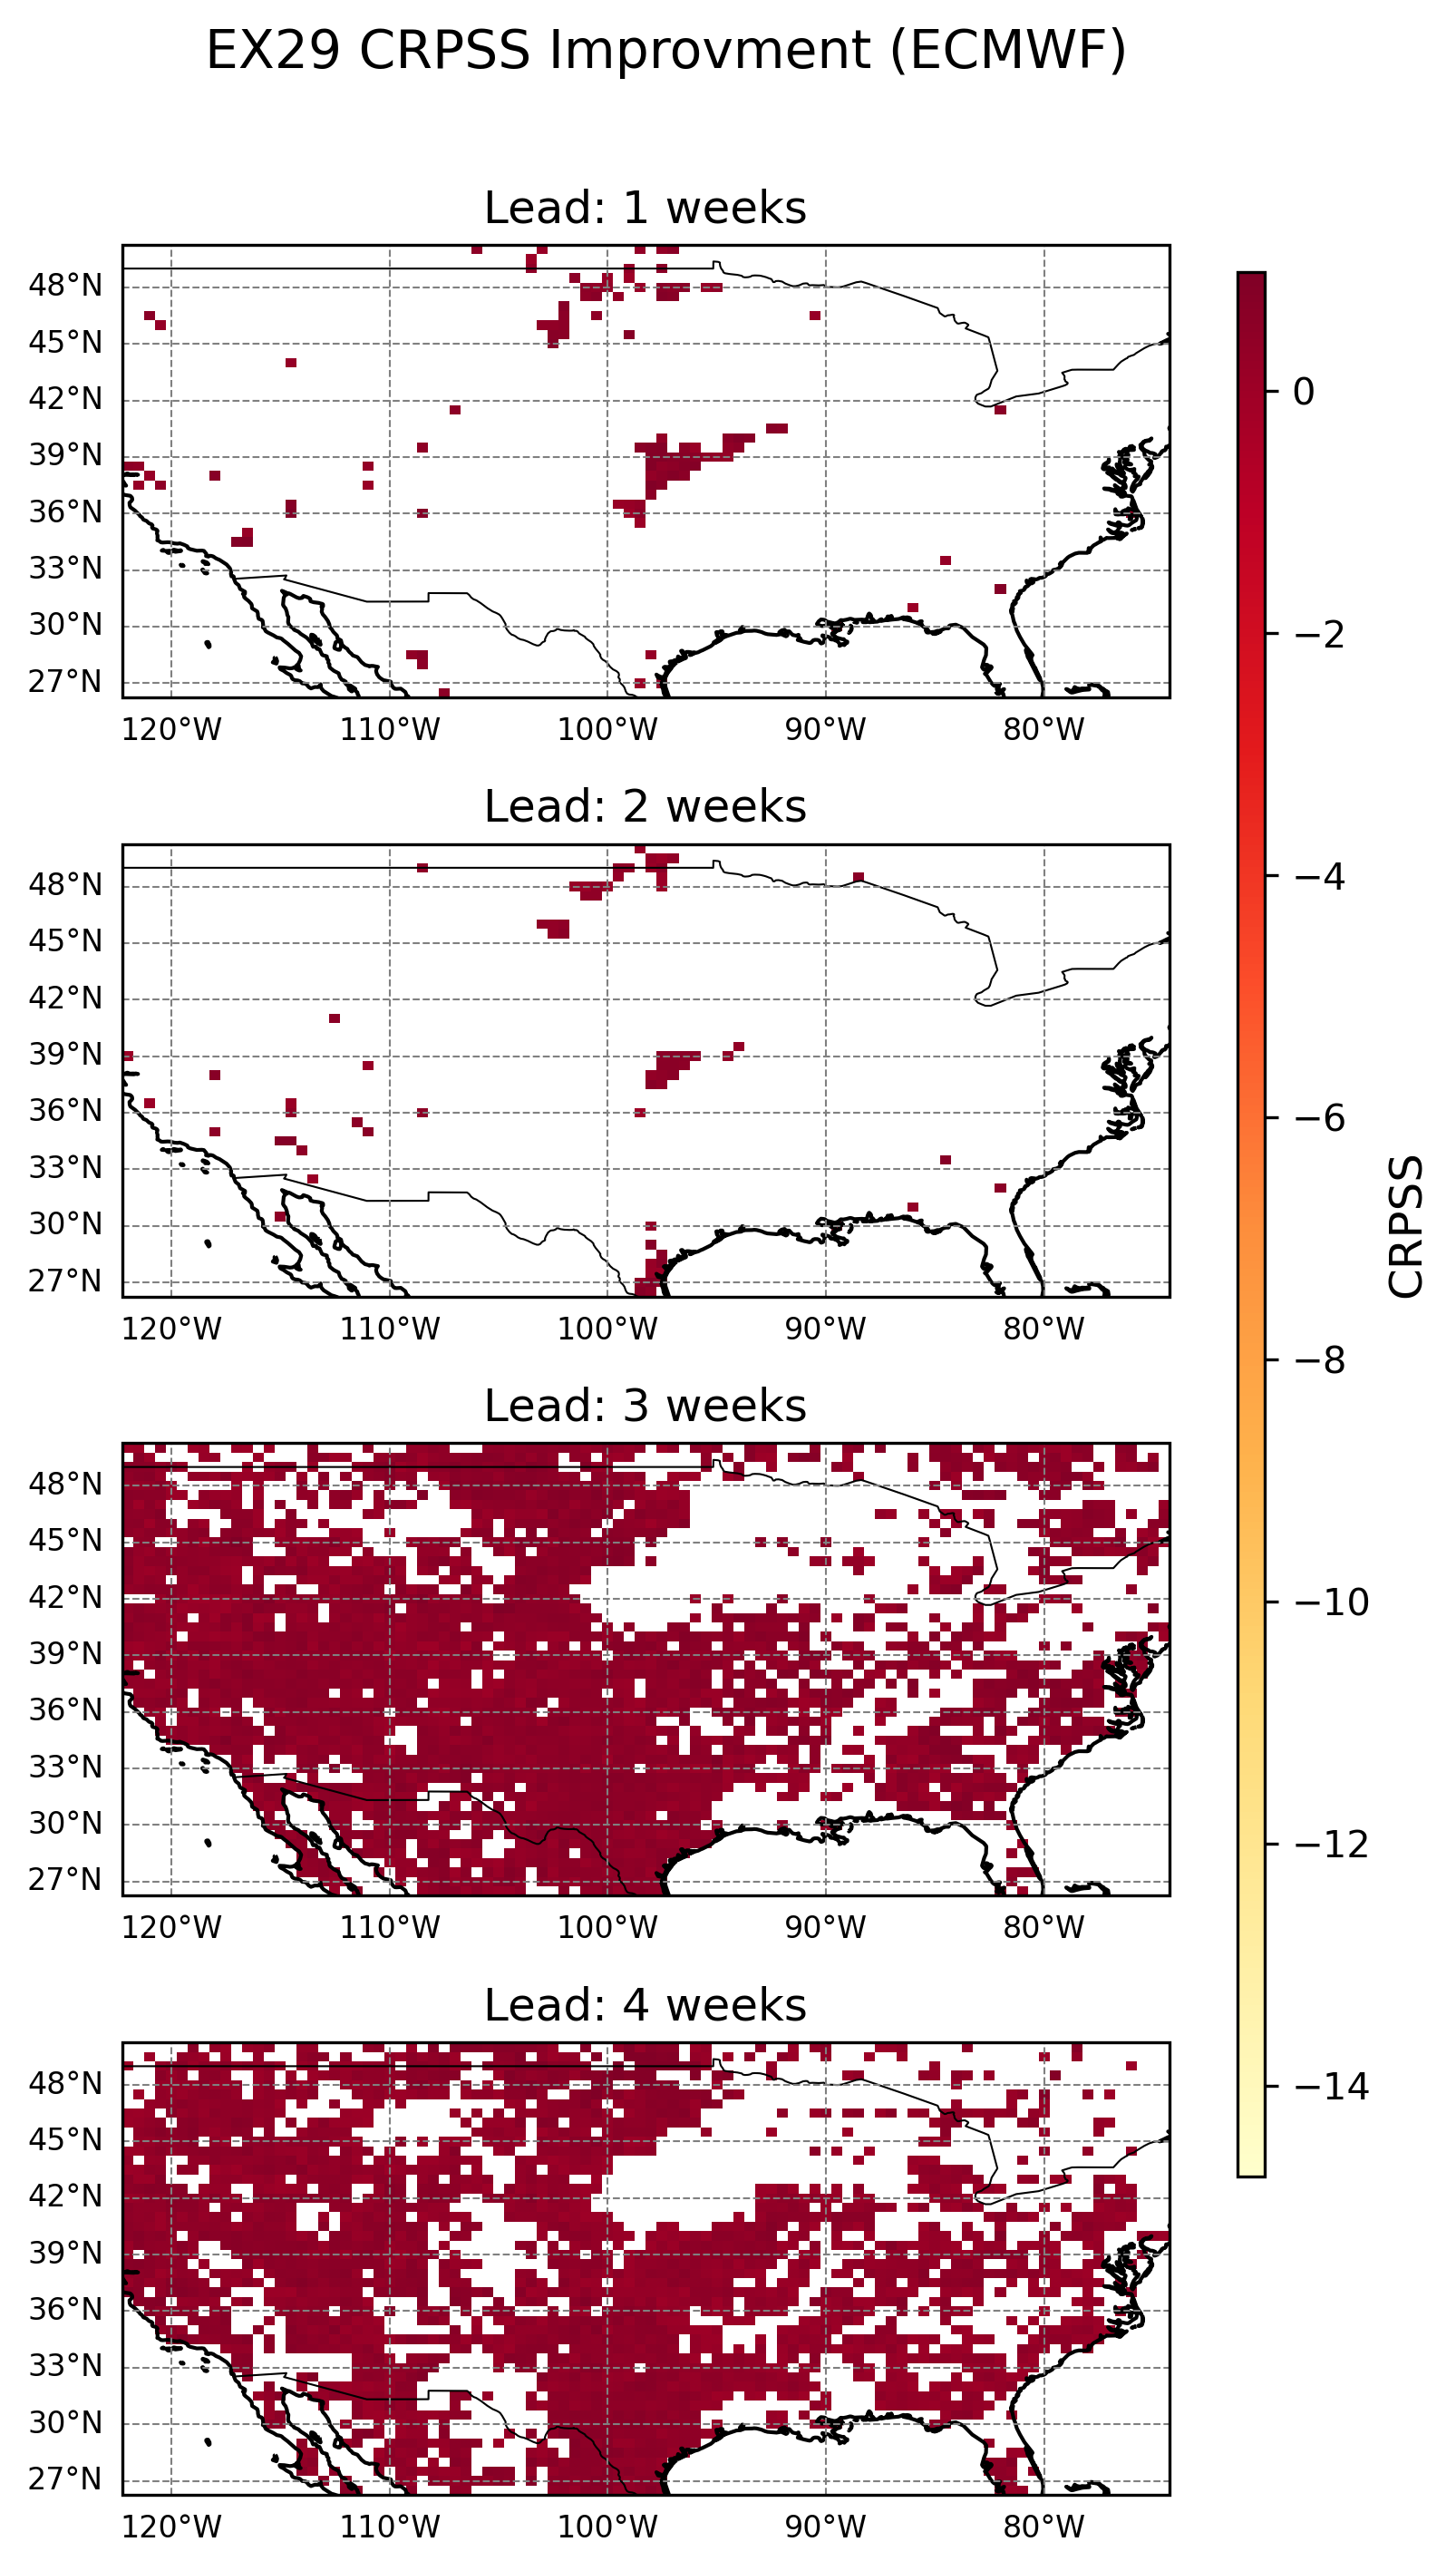

/glade/derecho/scratch/klesinger/tmp/ipykernel_84343/2083783228.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.93])


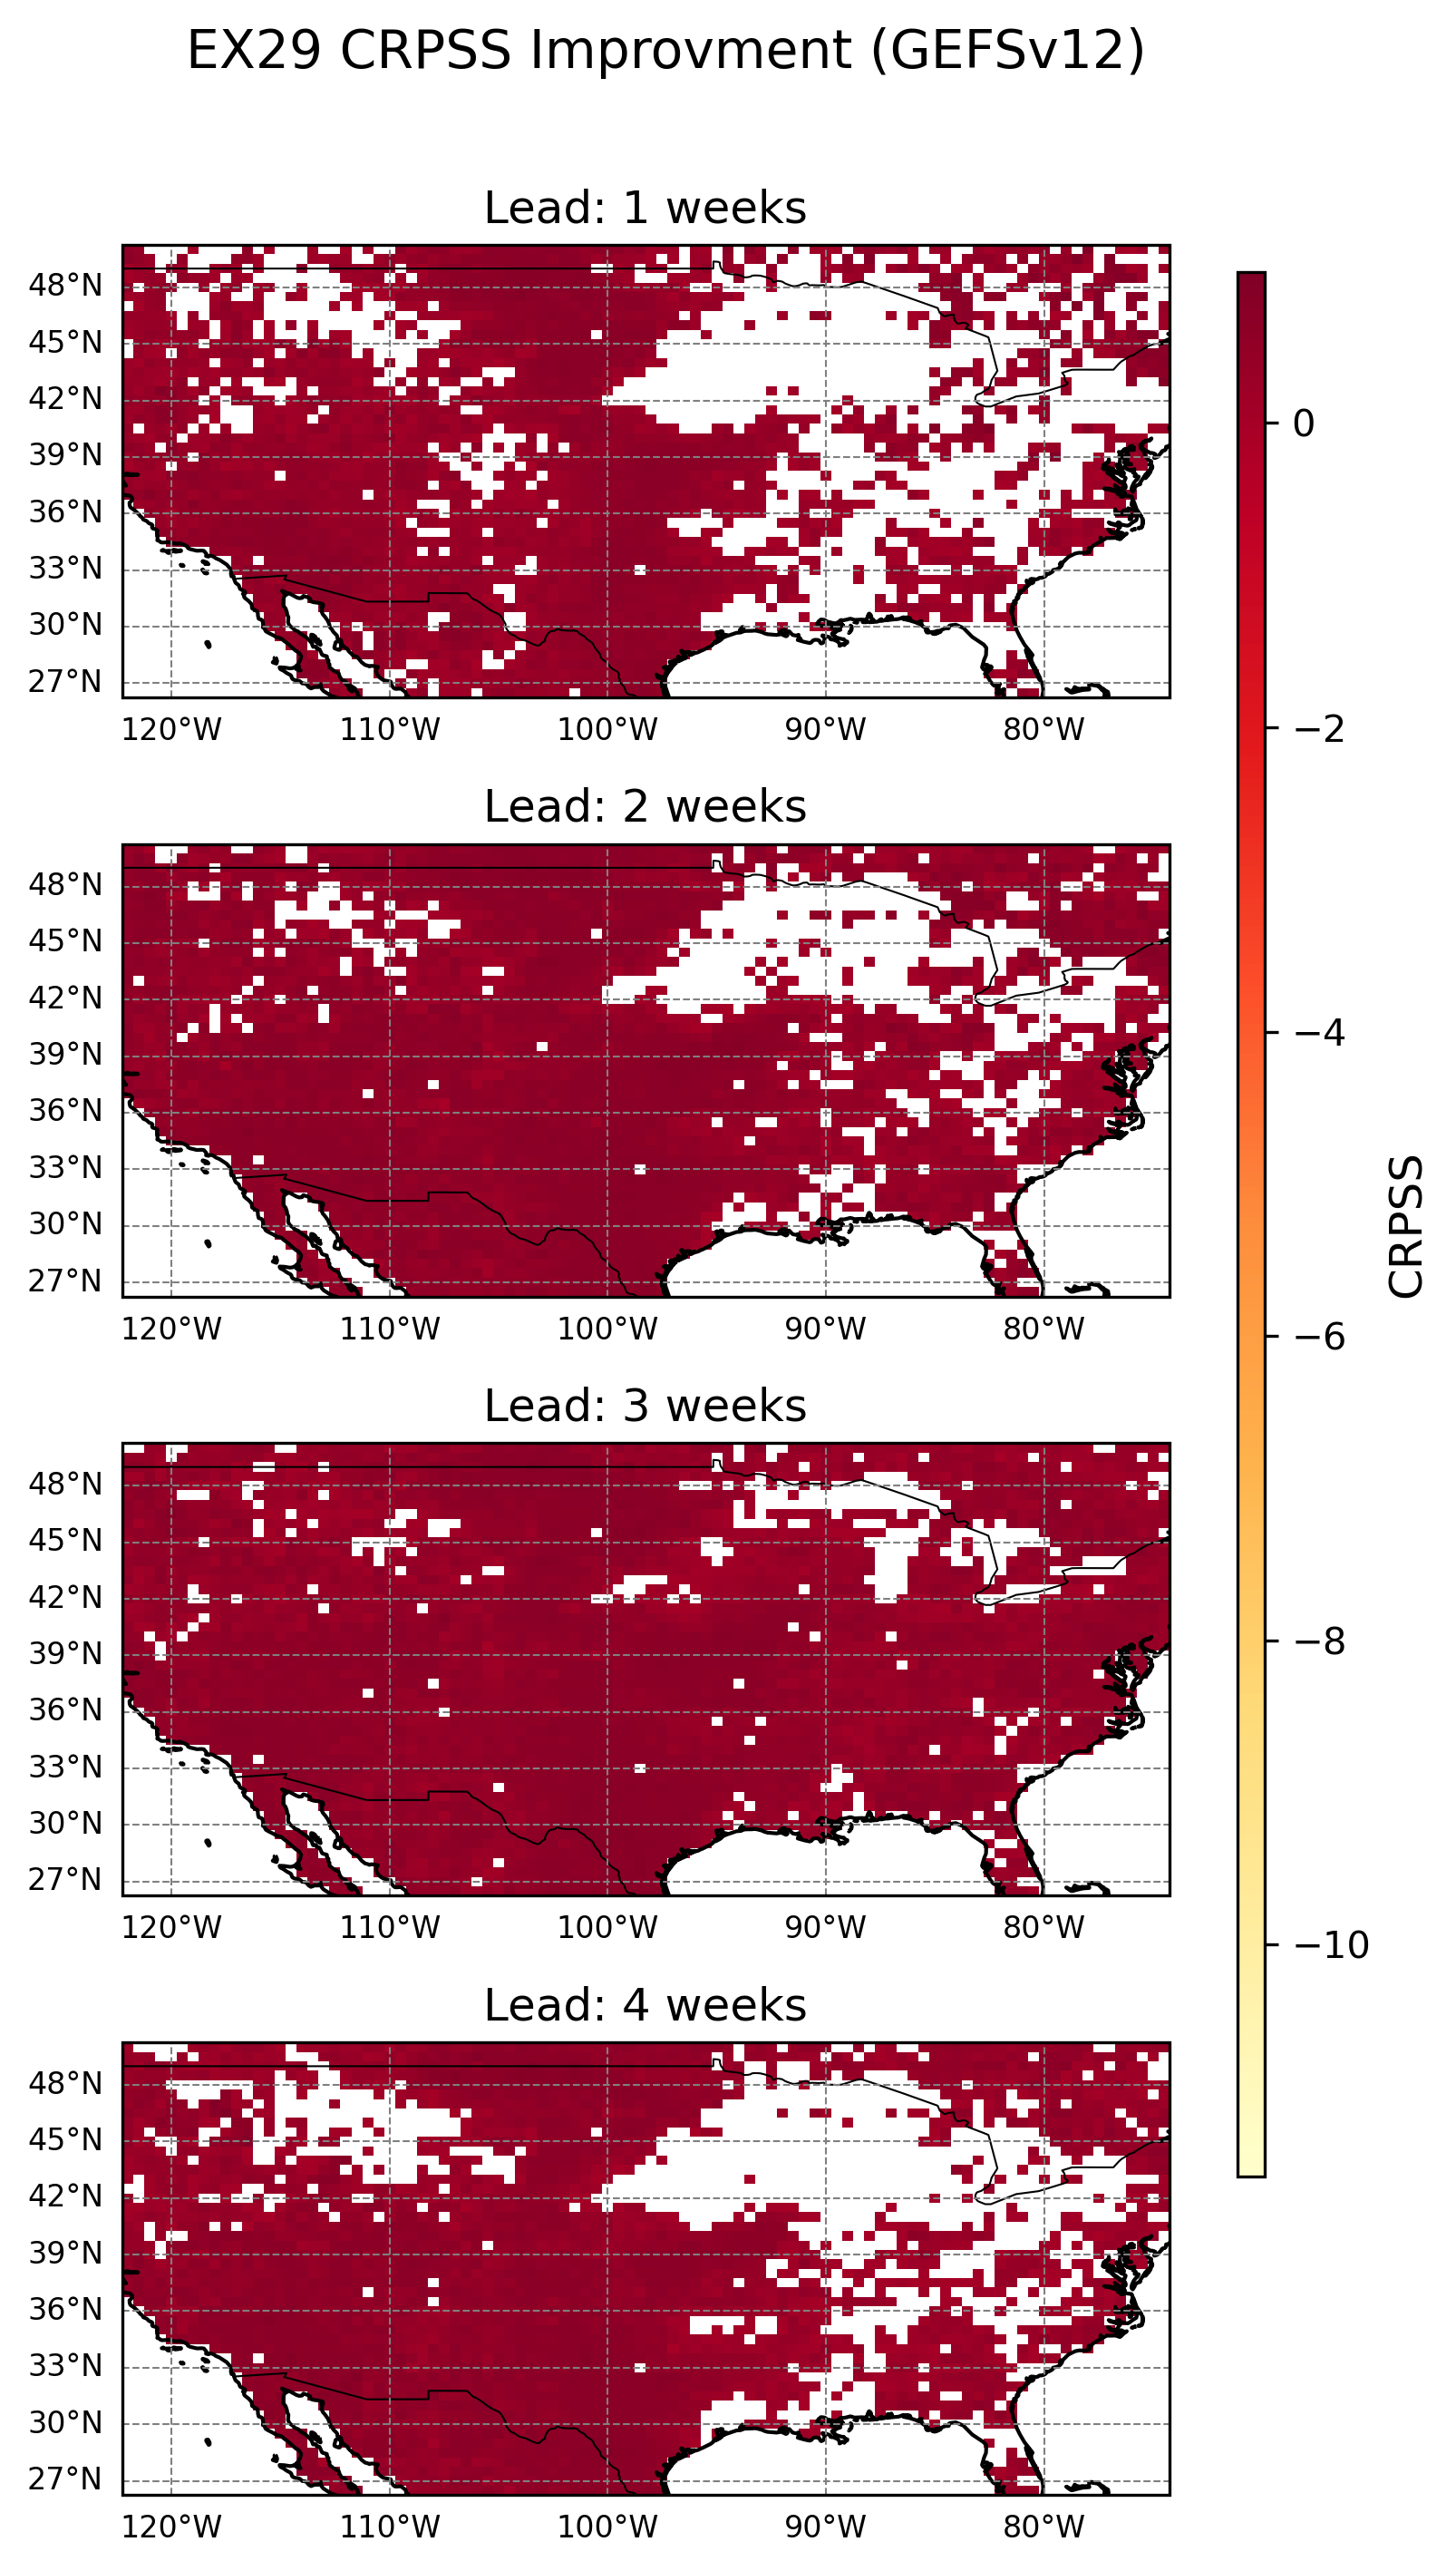

In [10]:


# def plot_CRPSS_values_improvement(region_name, obs_source, forecast_name):
#     '''Plot raw CRPSS values (no significance masking) for each lead time.'''

#     # Load the bootstrap file
#     file_bc = load_bootstrap_file_all_season(region_name, obs_source, f'{forecast_name}-BC')
#     unet = load_bootstrap_file_all_season(region_name, obs_source, f'EX29_{forecast_name}')

#     # Output directory
#     new_dir = f'Outputs/CRPSS_bootstrap/crpss_significant_improvement/{region_name}'
#     os.makedirs(new_dir, exist_ok=True)

#     # Extract raw CRPSS for 'initialized' forecast
#     crpss_bc = file_bc['crpss'].sel(skill='initialized', results='verify skill')
#     climatology_bc = file_bc['crpss'].sel(skill='climatology', results='verify skill')
#     crpss_bc = xr.where(crpss_bc > climatology_bc, crpss_bc, np.nan) #first condition
    
#     crpss_unet = unet['crpss'].sel(skill='initialized', results='verify skill')
#     climatology_unet = unet['crpss'].sel(skill='climatology', results='verify skill')
#     crpss_unet = xr.where(crpss_unet > climatology_unet, crpss_unet, np.nan) #second condition

#     '''All of the data after this is greater than climatology'''

#     low_ci_bc = file_bc['crpss'].sel(skill='initialized', results='low_ci')
#     high_ci_bc = file_bc['crpss'].sel(skill='initialized', results='high_ci')
    
#     low_ci_unet = unet['crpss'].sel(skill='initialized', results='low_ci')
#     high_ci_unet = unet['crpss'].sel(skill='initialized', results='high_ci')

#     #Check if it's higher than the lower confidence interval
#     crpss_unet = xr.where((crpss_unet >= low_ci_unet) & (crpss_unet <= high_ci_unet), crpss_unet, np.nan) #third condition
#     crpss_bc = xr.where((crpss_bc >= low_ci_bc) & (crpss_bc <= high_ci_bc), crpss_bc, np.nan) #fourth condition
    

#     pval_unet = unet['crpss'].sel(skill='initialized', results='p')
#     pval_bc = file_bc['crpss'].sel(skill='initialized', results='p')

#     '''Find where:
#     1.) bias corrected data crpss is greater than lower_ci
#     2.) unet data crpss is greater than ci
#     3.) where crpss_unet is > crpss_bc
#     '''
#     # Keep only UNET CRPSS where all 4 conditions are true
#     crpss_filtered = xr.where(crpss_unet>crpss_bc, crpss_unet, np.nan)
    
#     # crpss_filtered = xr.where(crpss_filtered>=0,crpss_filtered,np.nan)
    

#     leads = [0, 1, 2, 3]  # Lead indices (not lead days)

#     fig, axs = plt.subplots(
#         4, 1,  # 4 leads vertically stacked
#         figsize=(5, 10),
#         dpi=300,
#         subplot_kw={"projection": ccrs.PlateCarree()}
#     )

#     cmap = 'YlOrRd'
#     vmin, vmax = float(crpss_filtered.min()), float(crpss_filtered.max())
#     norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

#     for i, lead in enumerate(leads):
#         ax = axs[i]
#         ax.set_aspect('auto')

#         data = crpss_filtered.isel(lead=lead).mean(dim='init')
#         data = xr.where(data>=0,data,np.nan)

        
#         lon = file_bc.lon.values
#         lat = file_bc.lat.values
#         mesh_lon, mesh_lat = np.meshgrid(lon, lat)

#         im = ax.pcolormesh(mesh_lon, mesh_lat, data, cmap=cmap, norm=norm,
#                            transform=ccrs.PlateCarree(), shading='auto')

#         ax.coastlines()
#         ax.add_feature(cfeature.BORDERS, linewidth=0.5)
#         ax.set_title(f'Lead: {i+1} weeks', fontsize=12)

#         gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
#         gl.top_labels = gl.right_labels = False
#         gl.xformatter = LongitudeFormatter()
#         gl.yformatter = LatitudeFormatter()
#         gl.xlabel_style = {'size': 8}
#         gl.ylabel_style = {'size': 8}

#     # Add colorbar
#     cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
#     sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
#     sm.set_array([])
#     cbar = fig.colorbar(sm, cax=cbar_ax)
#     cbar.set_label('CRPSS', fontsize=12)

#     plt.suptitle(f"EX29 CRPSS Improvment ({forecast_name})", fontsize=14, y=0.94)
#     plt.tight_layout(rect=[0, 0, 0.9, 0.93])

#     save_file = f'{new_dir}/unet_greater_than_bias_corrected_and_significant_{forecast_name}_{obs_source}_Map.png'
#     plt.savefig(save_file, dpi=300)
#     plt.show()

# for forecast_name in ['ECMWF','GEFSv12']:
#     plot_CRPSS_values_improvement(region_name, obs_source, forecast_name)

/glade/derecho/scratch/klesinger/tmp/ipykernel_84343/106864061.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('YlOrRd').copy()
/glade/derecho/scratch/klesinger/tmp/ipykernel_84343/106864061.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('YlOrRd').copy()
/glade/derecho/scratch/klesinger/tmp/ipykernel_84343/106864061.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('YlOrRd').copy()
/glade/derecho/scratch/kl

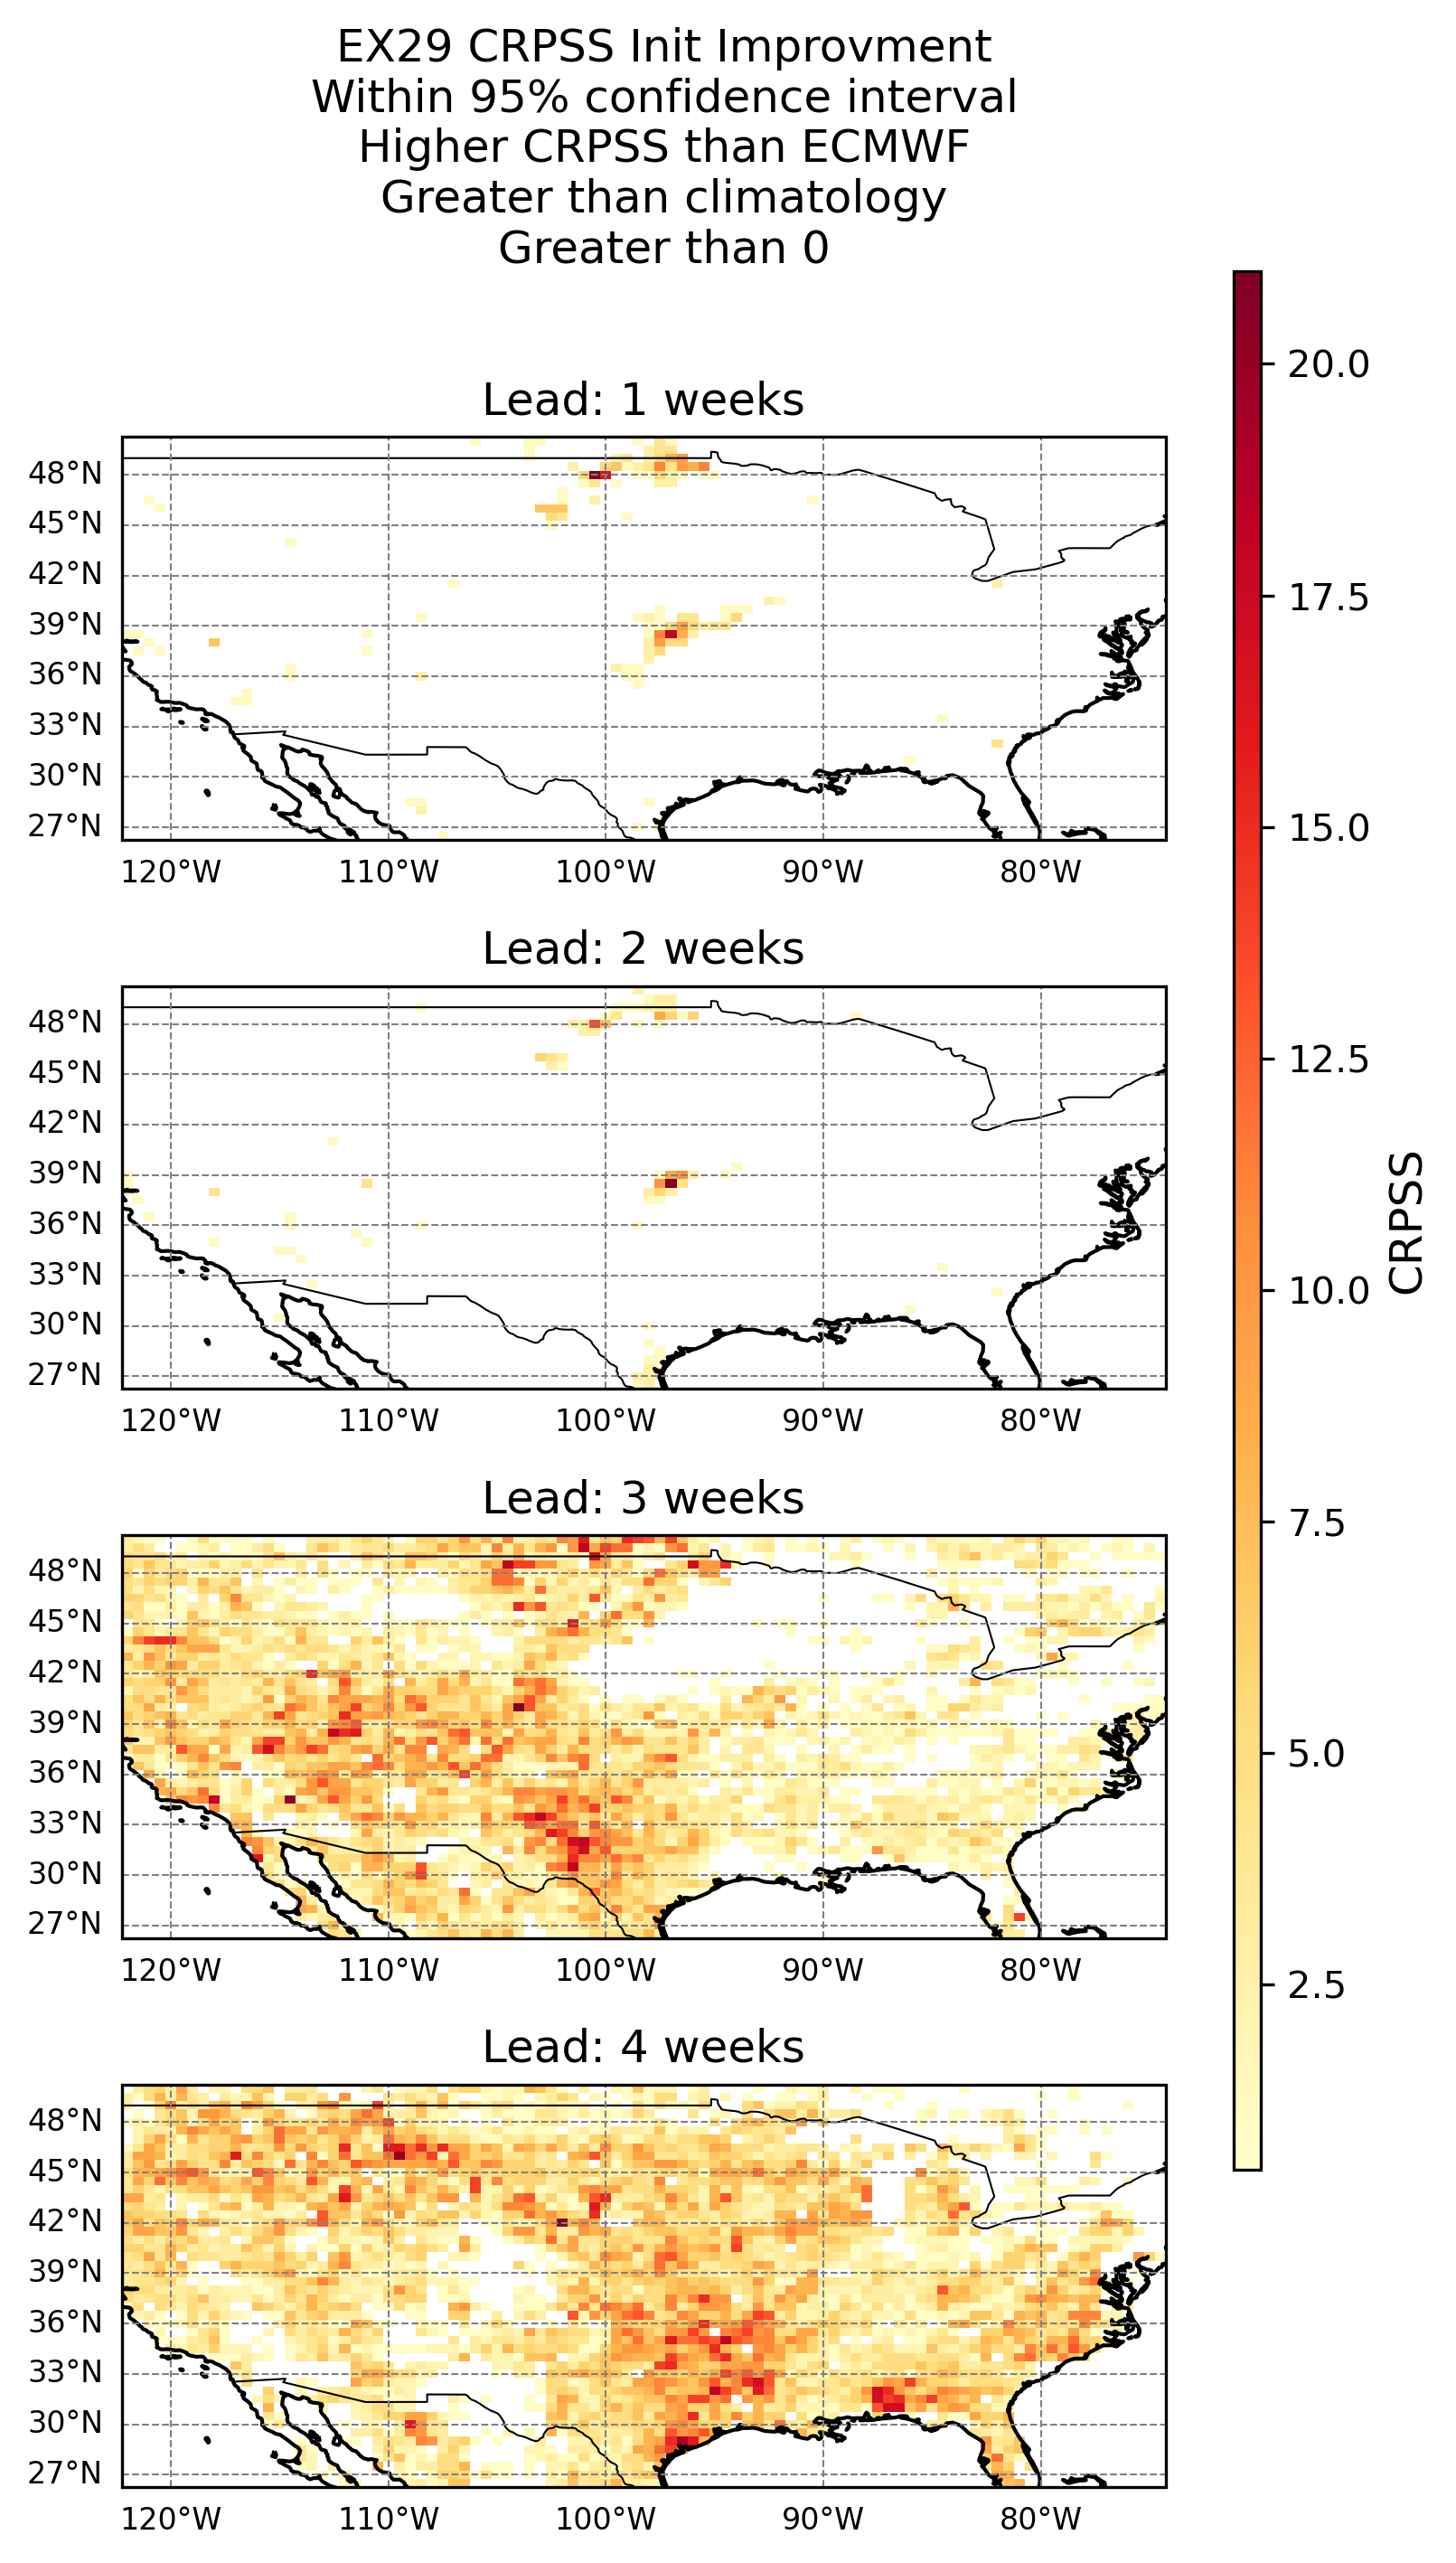

/glade/derecho/scratch/klesinger/tmp/ipykernel_84343/106864061.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('YlOrRd').copy()
/glade/derecho/scratch/klesinger/tmp/ipykernel_84343/106864061.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('YlOrRd').copy()
/glade/derecho/scratch/klesinger/tmp/ipykernel_84343/106864061.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('YlOrRd').copy()
/glade/derecho/scratch/kl

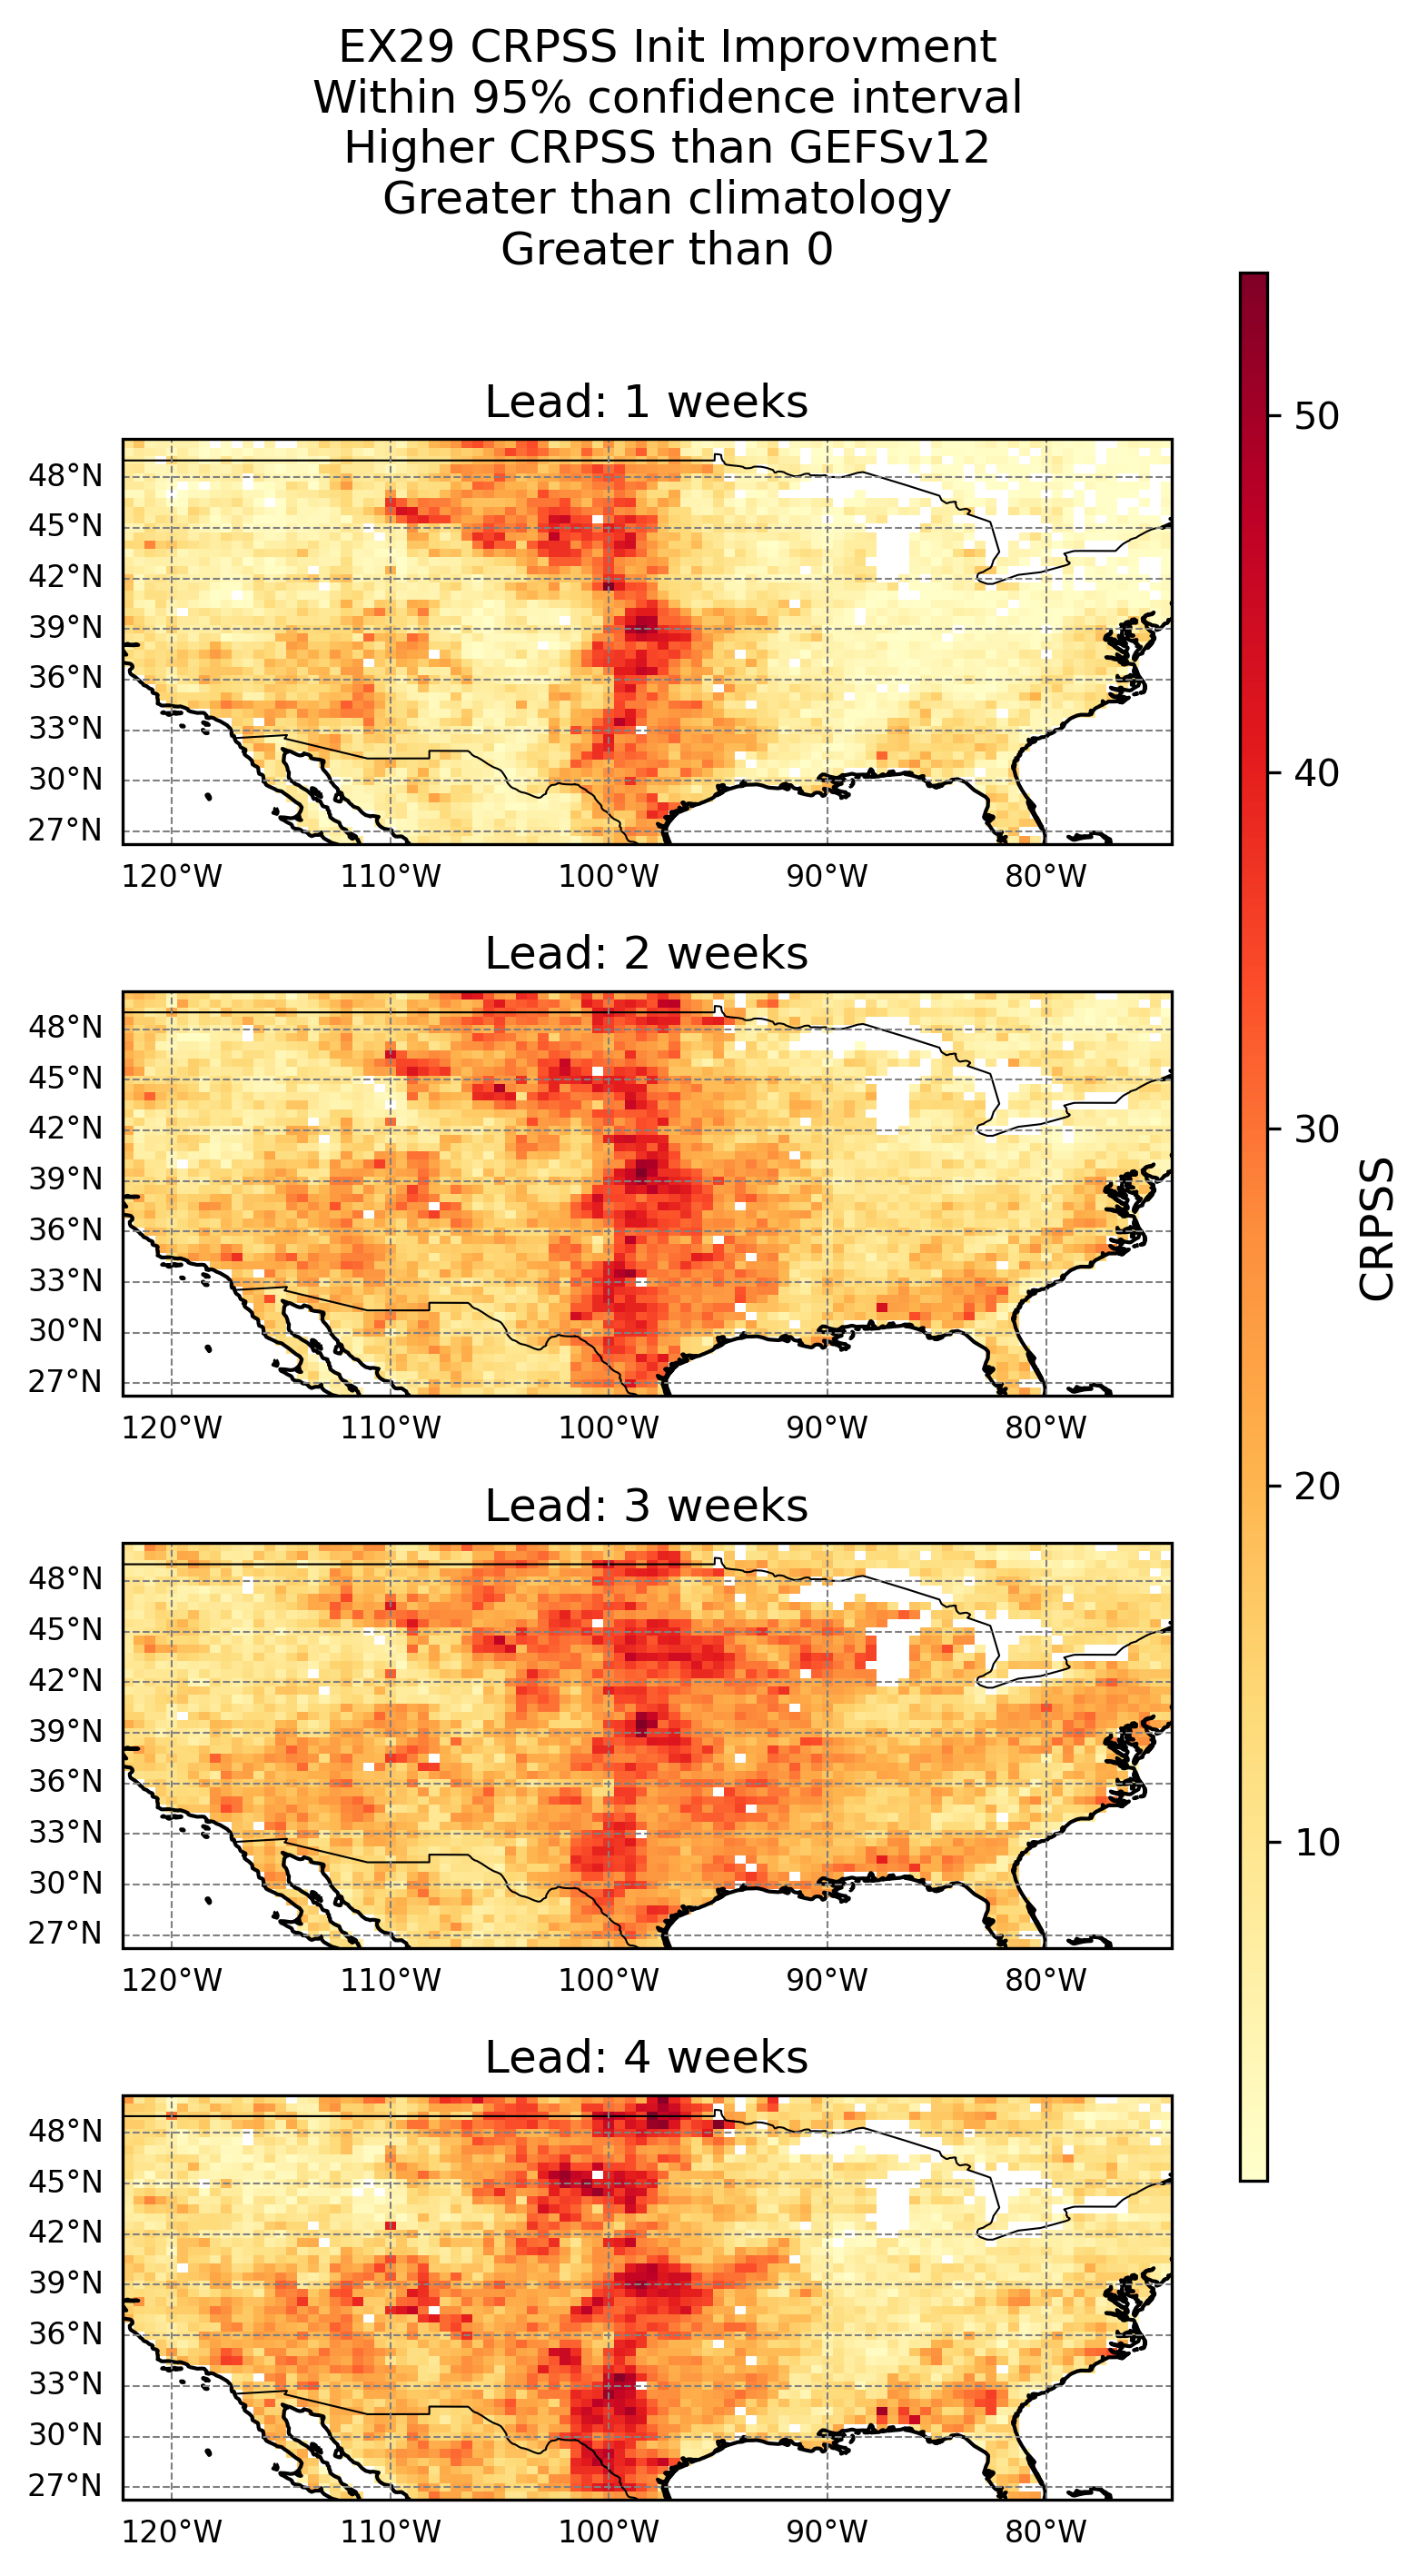

In [11]:


# def plot_CRPSS_init_count_improvement(region_name, obs_source, forecast_name):
#     '''Count the number of forecasts which are better than climatology.'''

#     # Load the bootstrap file
#     file_bc = load_bootstrap_file_all_season(region_name, obs_source, f'{forecast_name}-BC')
#     unet = load_bootstrap_file_all_season(region_name, obs_source, f'EX29_{forecast_name}')

#     init_counts = len(file_bc.init.values)

#     # Output directory
#     new_dir = f'Outputs/CRPSS_bootstrap/init_count_improvement/{region_name}'
#     os.makedirs(new_dir, exist_ok=True)

#     # Extract raw CRPSS for 'initialized' forecast
#     crpss_bc = file_bc['crpss'].sel(skill='initialized', results='verify skill')
#     climatology_bc = file_bc['crpss'].sel(skill='climatology', results='verify skill')
#     crpss_bc = xr.where(crpss_bc > climatology_bc, crpss_bc, np.nan) #first condition
#     # crpss_bc = xr.where(crpss_bc > 0, crpss_bc, np.nan) #greater than 0
#     # crpss_bc_sum = crpss_bc.sum(dim='init')
    
#     crpss_unet = unet['crpss'].sel(skill='initialized', results='verify skill')
#     climatology_unet = unet['crpss'].sel(skill='climatology', results='verify skill')
#     crpss_unet = xr.where(crpss_unet > climatology_unet, crpss_unet, np.nan) #second condition

#     '''All of the data after this is greater than climatology'''

#     low_ci_bc = file_bc['crpss'].sel(skill='initialized', results='low_ci')
#     high_ci_bc = file_bc['crpss'].sel(skill='initialized', results='high_ci')
    
#     low_ci_unet = unet['crpss'].sel(skill='initialized', results='low_ci')
#     high_ci_unet = unet['crpss'].sel(skill='initialized', results='high_ci')

#     #Check if it's higher than the lower confidence interval
#     crpss_unet = xr.where((crpss_unet >= low_ci_unet) & (crpss_unet <= high_ci_unet), crpss_unet, np.nan) #third condition
#     crpss_bc = xr.where((crpss_bc >= low_ci_bc) & (crpss_bc <= high_ci_bc), crpss_bc, np.nan) #fourth condition

#     crpss_unet = xr.where (crpss_unet> crpss_bc, crpss_unet, np.nan)
    
#     crpss_unet = xr.where(crpss_unet > 0 , 1, np.nan)
#     crpss_unet = crpss_unet.sum(dim='init')
    

#     pval_unet = unet['crpss'].sel(skill='initialized', results='p')
#     pval_bc = file_bc['crpss'].sel(skill='initialized', results='p')


#     leads = [0, 1, 2, 3]  # Lead indices (not lead days)

#     fig, axs = plt.subplots(
#         4, 1,  # 4 leads vertically stacked
#         figsize=(5, 10),
#         dpi=300,
#         subplot_kw={"projection": ccrs.PlateCarree()}
#     )


#     for i, lead in enumerate(leads):
#         ax = axs[i]
#         ax.set_aspect('auto')

#         data = crpss_unet.isel(lead=lead)

#         cmap = cm.get_cmap('YlOrRd').copy()
#         cmap.set_under('white')  # color for values below vmin
#         cmap.set_bad('white')    # color for np.nan
#         # You want 0 to show as white and the rest scaled upwards
#         vmin = 0.5
#         vmax = float(data.max())
#         norm = colors.Normalize(vmin=vmin, vmax=vmax)
#         lon = file_bc.lon.values
#         lat = file_bc.lat.values
#         mesh_lon, mesh_lat = np.meshgrid(lon, lat)

#         im = ax.pcolormesh(mesh_lon, mesh_lat, data, cmap=cmap, norm=norm,
#                            transform=ccrs.PlateCarree(), shading='auto')

#         ax.coastlines()
#         ax.add_feature(cfeature.BORDERS, linewidth=0.5)
#         ax.set_title(f'Lead: {i+1} weeks', fontsize=12)

#         gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
#         gl.top_labels = gl.right_labels = False
#         gl.xformatter = LongitudeFormatter()
#         gl.yformatter = LatitudeFormatter()
#         gl.xlabel_style = {'size': 8}
#         gl.ylabel_style = {'size': 8}

#     # Add colorbar
#     cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
#     sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
#     sm.set_array([])
#     cbar = fig.colorbar(sm, cax=cbar_ax)
#     cbar.set_label('CRPSS', fontsize=12)

#     plt.suptitle(f"EX29 CRPSS Init Improvment\nWithin 95% confidence interval\nHigher CRPSS than {forecast_name}\nGreater than climatology\nGreater than 0", fontsize=12, y=0.94)
#     plt.tight_layout(rect=[0, 0, 0.9, 0.93])

#     save_file = f'{new_dir}/unet_init_count_improvement_{forecast_name}_{obs_source}_Map.png'
#     plt.savefig(save_file, dpi=300)
#     plt.show()

# for forecast_name in ['ECMWF','GEFSv12']:
#     plot_CRPSS_init_count_improvement(region_name, obs_source, forecast_name)